<a href="https://colab.research.google.com/github/helonayala/mpcbook-ch8-casadi-python/blob/main/ex87_00_zz_xreftime_receding_TsMPC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ex87_00_zz_xreftime_receding_TsMPC (Python)

Multi-rate closed-loop setup: fast simulation time and slower MPC updates.


In [1]:
!pip -q install casadi matplotlib numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 8.9 MB/s eta 0:00:00


CasADi - 2026-02-16 10:01:15 WARNING("The options 't0', 'tf', 'grid' and 'output_t0' have been deprecated.
The same functionality is provided by providing additional input arguments to the 'integrator' function, in particular:
 * Call integrator(..., t0, tf, options) for a single output time, or
 * Call integrator(..., t0, grid, options) for multiple grid points.
The legacy 'output_t0' option can be emulated by including or excluding 't0' in 'grid'.
Backwards compatibility is provided in this release only.") [.../casadi/core/integrator.cpp:692]



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



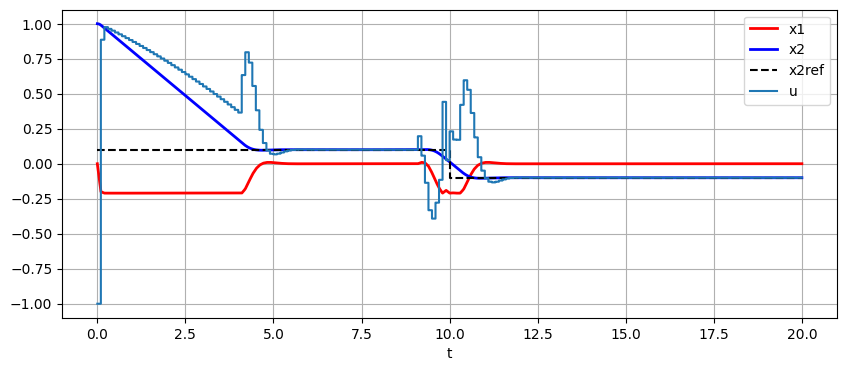

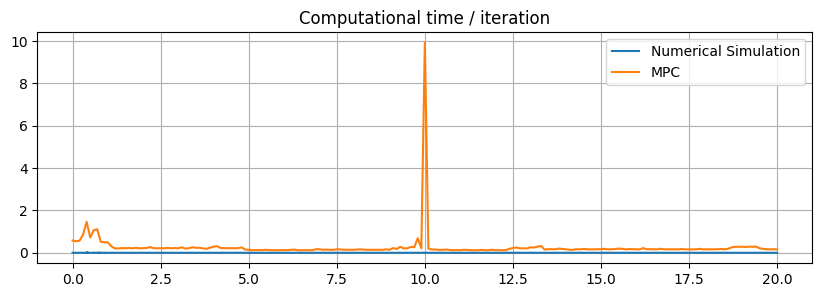

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from casadi import SX, MX, DM, Function, integrator, nlpsol, vertcat, horzcat


def vcat(lst):
    return vertcat(*[DM(x) if not hasattr(x, 'is_symbolic') else x for x in lst])

import time

x1 = SX.sym('x1')
x2 = SX.sym('x2')
u = SX.sym('u')

x1_dot = (1 - x2**2) * x1 - x2 + u
x2_dot = x1

ocp = {'x': vertcat(x1, x2), 'u': u, 'ode': vertcat(x1_dot, x2_dot)}

N = 10
nx = int(ocp['x'].numel())
nu = int(ocp['u'].numel())

data = {
    'T': 20.0,
    'Ts': 0.001,
    'TsMPC': 0.1,
    'x0': np.array([0.0, 1.0]),
    'u_min': -1.0,
    'u_max': 1.0,
    'x_min': np.array([-0.21, -np.inf]),
    'x_max': np.array([np.inf, np.inf]),
    'u_guess': 0.0,
    'x_guess': np.array([0.0, 0.0]),
    'tol': 1e-8,
}

data['tvec'] = np.arange(0.0, data['T'] + N * data['TsMPC'] + data['TsMPC'], data['TsMPC'])
data['x2ref'] = np.where(data['tvec'] < 10.0, 0.1, -0.1)

dae = {'x': ocp['x'], 'p': ocp['u'], 'ode': ocp['ode']}
F = integrator('F', 'cvodes', dae, {'tf': data['TsMPC'], 'reltol': data['tol'], 'abstol': data['tol']})
Fsim = integrator('Fsim', 'cvodes', dae, {'tf': data['Ts'], 'reltol': data['tol'], 'abstol': data['tol']})

w, lbw, ubw, w0 = [], [], [], []
g, lbg, ubg = [], [], []
J = 0
P = []
x_plot, u_plot = [], []

xk = MX.sym('x0', nx)
w.append(xk)
lbw.append(data['x_min'])
ubw.append(data['x_max'])
w0.append(data['x_guess'])

Pk = MX.sym('P0', nx)
g.append(xk - Pk)
lbg.append(np.zeros(nx))
ubg.append(np.zeros(nx))
P.append(Pk)
x_plot.append(xk)

for k in range(1, N + 1):
    uk_sym = MX.sym(f'u{k}', nu)
    w.append(uk_sym)
    lbw.append(data['u_min'])
    ubw.append(data['u_max'])
    w0.append(data['u_guess'])

    Fk = F(x0=xk, p=uk_sym)
    xnext = Fk['xf']

    Pk = MX.sym(f'P{k}', 1)
    J = J + 1e3 * (xnext[1] - Pk)**2 + uk_sym**2
    P.append(Pk)

    xk = MX.sym(f'x{k}', nx)
    w.append(xk)
    lbw.append(data['x_min'])
    ubw.append(data['x_max'])
    w0.append(data['x_guess'])
    g.append(xk - xnext)
    lbg.append(np.zeros(nx))
    ubg.append(np.zeros(nx))

    u_plot.append(uk_sym)
    x_plot.append(xk)

w = vertcat(*w)
lbw = vcat(lbw)
ubw = vcat(ubw)
w0 = vcat(w0)
g = vertcat(*g)
lbg = vcat(lbg)
ubg = vcat(ubg)
P = vertcat(*P)

nlp = {'x': w, 'g': g, 'f': J, 'p': P}
solver = nlpsol('solver', 'ipopt', nlp, {'ipopt.print_level': 0, 'print_time': 0})

traj = Function('traj', [w], [horzcat(*x_plot), horzcat(*u_plot)], ['w'], ['x', 'u'])
warm = Function('warm', [horzcat(*x_plot), horzcat(*u_plot)], [w], ['x', 'u'], ['w'])

xsim = data['x0'].reshape(-1, 1)
usim = []
tvec = []
tvec_mpc = []
dtvec = []
dtvec_mpc = []

nMPC = 0
uk = np.array([0.0])
steps = int(round(data['T'] / data['Ts']))
mpc_every = int(round(data['TsMPC'] / data['Ts']))

for k in range(steps + 1):
    t = k * data['Ts']

    if k % mpc_every == 0:
        x2refvec = data['x2ref'][nMPC:nMPC + N]
        tic = time.perf_counter()
        pval = np.r_[xsim[:, -1], x2refvec]
        sol = solver(x0=w0, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg, p=DM(pval))
        dt1 = time.perf_counter() - tic
        tvec_mpc.append(t)
        dtvec_mpc.append(dt1)

        x_opt, u_opt = traj(sol['x'])
        x_opt = np.array(x_opt.full())
        u_opt = np.array(u_opt.full())

        uk = u_opt[:, 0]
        x_ws = np.c_[x_opt[:, 1:], x_opt[:, -1]]
        u_ws = np.c_[u_opt[:, 1:], u_opt[:, -1]]
        w0 = warm(x=x_ws, u=u_ws)['w']
        nMPC += 1

    tic = time.perf_counter()
    xk1 = np.array(Fsim(x0=DM(xsim[:, -1]), p=DM(uk))['xf'].full()).reshape(-1)
    dt = time.perf_counter() - tic

    xsim = np.c_[xsim, xk1]
    usim.append(uk)
    tvec.append(t)
    dtvec.append(dt)

xsim = xsim[:, :-1]
usim = np.array(usim).T
tvec = np.array(tvec)

plt.figure(figsize=(10, 4))
plt.plot(tvec, xsim[0, :], 'r-', linewidth=2, label='x1')
plt.plot(tvec, xsim[1, :], 'b-', linewidth=2, label='x2')
plt.step(data['tvec'][:-N], data['x2ref'][:-N], where='post', color='k', linestyle='--', label='x2ref')
plt.step(tvec, usim[0, :], where='post', label='u')
plt.grid(True)
plt.xlabel('t')
plt.legend()
plt.show()

plt.figure(figsize=(10, 3))
plt.title('Computational time / iteration')
plt.plot(tvec, dtvec, label='Numerical Simulation')
plt.plot(tvec_mpc, dtvec_mpc, label='MPC')
plt.grid(True)
plt.legend()
plt.show()
